In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


* Total 21 columns are in the dataset
* Here TotalCharges column is an object but it should be numerical. So, it must be converted into numerical before further operaion

In [4]:
df.isnull().sum().sum()

0

In [5]:
df['TotalCharges'].value_counts()

          11
20.2      11
19.75      9
20.05      8
19.9       8
          ..
6849.4     1
692.35     1
130.15     1
3211.9     1
6844.5     1
Name: TotalCharges, Length: 6531, dtype: int64

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

In [7]:
df['TotalCharges'].dtype

dtype('float64')

In [8]:
df['TotalCharges'].isnull().sum()

11

In [9]:
df.dropna(axis=0, inplace= True)

In [10]:
df.isnull().sum().sum()

0

In [11]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Now There is no missing value in any column

In [12]:
# CustomerID is not relevent column and not useful for prediction. We can drop the columns
df = df.drop('customerID', axis = 1)

In [13]:
df.shape

(7032, 20)

In [14]:
df['gender'].value_counts()

Male      3549
Female    3483
Name: gender, dtype: int64

In [15]:
churn_counts = df['Churn'].value_counts()
churn_counts

No     5163
Yes    1869
Name: Churn, dtype: int64

* data is imbalance. therefore data must be sampled in such way that proper representation should present in the final model development 

In [16]:
#Convert binary yes/no to 1/0
binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling','Churn']

df[binary_cols] = df[binary_cols].replace({'Yes':1,'No':0})

In [17]:
#Create new columns:
#▪ TenureGroup (0–12 months, 13–24, etc.)
bins= [0, 12, 24, 36, 48, 60, 72]
labels = ['0-12 months', '13-24 months', '25-36 months', '37-48 months', '49-60 months', '61-72months']
df['TenureGroup'] = pd.cut(df['tenure'], bins = bins, labels = labels, right = True)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup
0,Female,0,1,0,1,0,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0,0-12 months
1,Male,0,0,0,34,1,No,DSL,Yes,No,...,No,No,No,One year,0,Mailed check,56.95,1889.50,0,25-36 months
2,Male,0,0,0,2,1,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1,0-12 months
3,Male,0,0,0,45,0,No phone service,DSL,Yes,No,...,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0,37-48 months
4,Female,0,0,0,2,1,No,Fiber optic,No,No,...,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1,0-12 months


In [18]:
#new column AvgMonthlySpend
df['AvgMonthlySpend'] = df['TotalCharges'] / df['tenure']
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,AvgMonthlySpend
0,Female,0,1,0,1,0,No phone service,DSL,No,Yes,...,No,No,Month-to-month,1,Electronic check,29.85,29.85,0,0-12 months,29.850000
1,Male,0,0,0,34,1,No,DSL,Yes,No,...,No,No,One year,0,Mailed check,56.95,1889.50,0,25-36 months,55.573529


### Some Exploratory data analysis is required to understand the data better

In [19]:
# What percentage of customers churned vs retained?
percentage_churn = df['Churn'].value_counts(normalize = True) *100
print("Customer Counts:")
print(churn_counts)

print("\nCustomer Percentage:")
print(percentage_churn)

Customer Counts:
No     5163
Yes    1869
Name: Churn, dtype: int64

Customer Percentage:
0    73.421502
1    26.578498
Name: Churn, dtype: float64


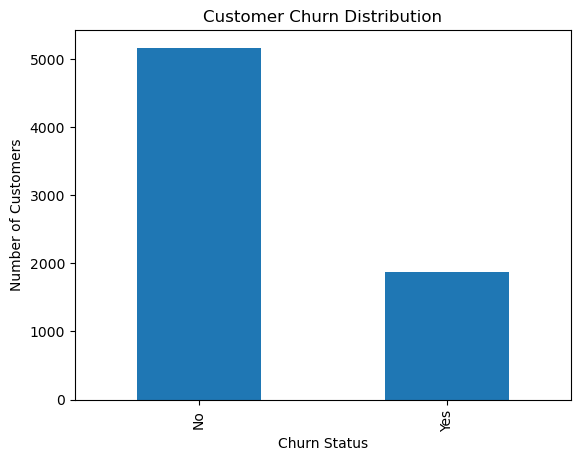

In [62]:
df['Churn'].value_counts().plot(kind='bar')

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

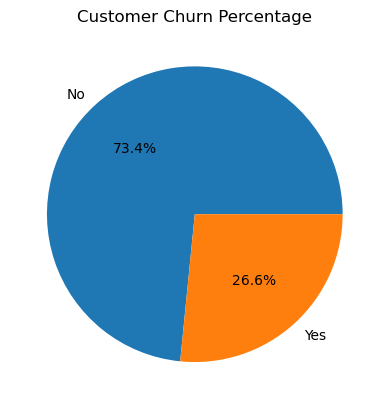

In [63]:
df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Customer Churn Percentage")
plt.ylabel("")
plt.show()

* Out of the total customers, 26.54% churned while 73.46% were retained. This indicates a significant customer attrition rate. Identifying the factors contributing to churn is essential for telecom companies to design targeted retention strategies.

In [79]:
# Which contract type has highest churn?
churn_contract = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

print(churn_contract)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665


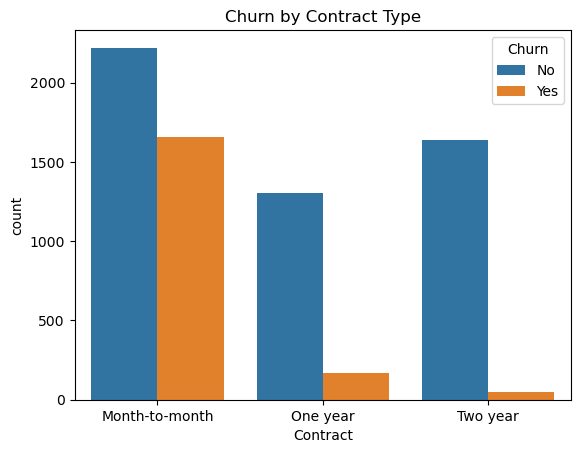

In [80]:
sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Churn by Contract Type")
plt.show()

* Customers with month-to-month contracts show the highest churn rate, exceeding 40%, while customers with two-year contracts have the lowest churn rate (around 3%). This indicates that longer contractual commitments significantly improve customer retention.

### Does monthly charges affect churn?

In [83]:
def risk_level(charge):
    if charge<40:
        return "Low Risk"
    elif charge< 70:
        return "Medium Risk"
    else:
        return "High Risk"
    
df['Churn Risk'] = df['MonthlyCharges'].apply(risk_level)


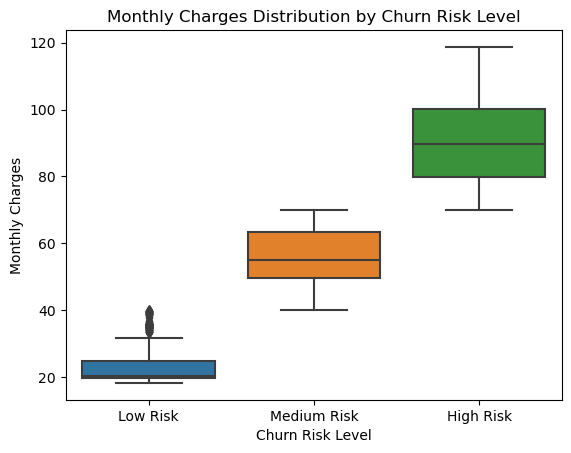

In [87]:
sns.boxplot(x='Churn Risk', y='MonthlyCharges', data=df)

plt.title("Monthly Charges Distribution by Churn Risk Level")
plt.xlabel("Churn Risk Level")
plt.ylabel("Monthly Charges")

plt.show()

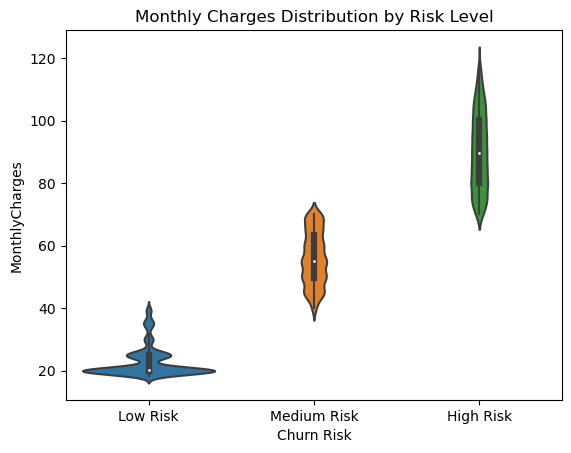

In [89]:
sns.violinplot(x='Churn Risk', y='MonthlyCharges', data=df)

plt.title("Monthly Charges Distribution by Risk Level")
plt.show()

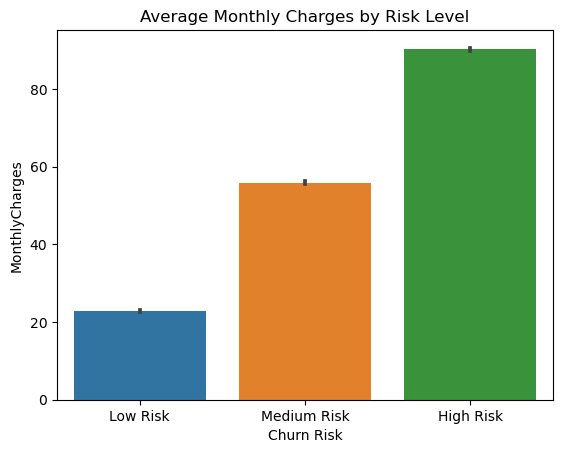

In [91]:
sns.barplot(x='Churn Risk', y='MonthlyCharges', data=df)

plt.title("Average Monthly Charges by Risk Level")
plt.show()

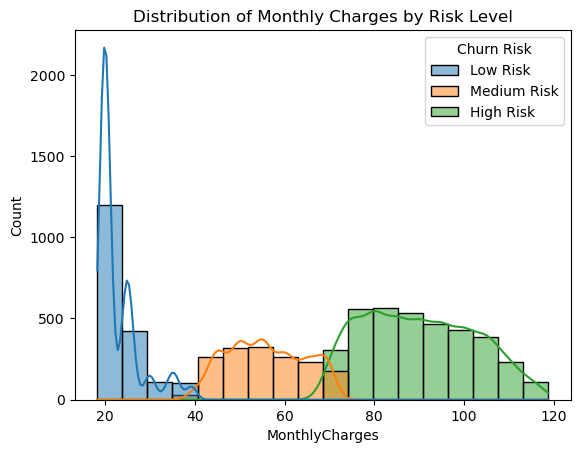

In [93]:
sns.histplot(data=df, x="MonthlyCharges", hue="Churn Risk", kde=True)
plt.title("Distribution of Monthly Charges by Risk Level")
plt.show()

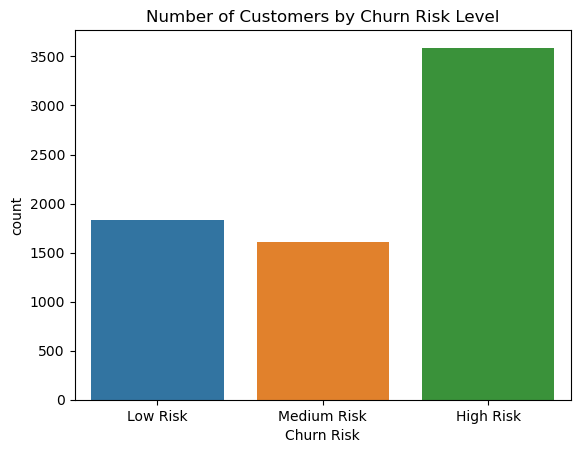

In [94]:
sns.countplot(x="Churn Risk", data=df)

plt.title("Number of Customers by Churn Risk Level")
plt.show()

* The analysis shows that customers categorized as high churn risk tend to have significantly higher monthly charges compared to low-risk customers. This suggests that pricing may influence customer churn behavior, and telecom companies should consider targeted pricing strategies or loyalty discounts to retain high-paying customers.

In [81]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

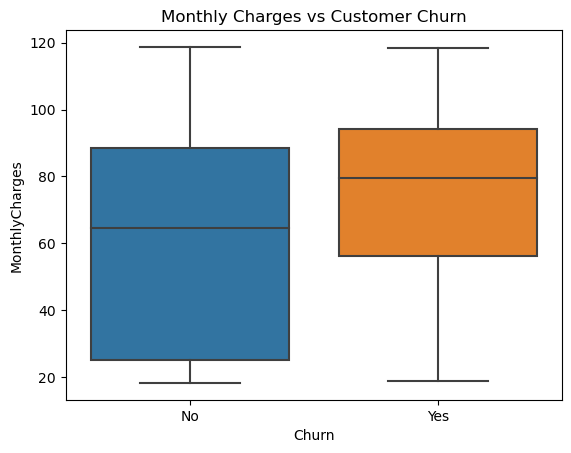

In [82]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.title("Monthly Charges vs Customer Churn")
plt.show()

### Does tenure (customer lifetime) reduce churn?

In [95]:
df.groupby("Churn")["tenure"].mean()

Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64

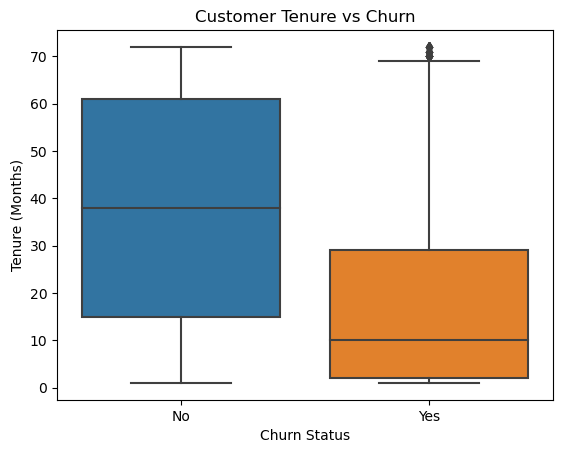

In [96]:
sns.boxplot(x="Churn", y="tenure", data=df)

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn Status")
plt.ylabel("Tenure (Months)")
plt.show()

* The analysis indicates that customer tenure has a strong negative relationship with churn. Customers with shorter tenure are significantly more likely to churn, while long-term customers show greater loyalty and retention. This suggests that telecom companies should focus on improving customer experience during the early stages of the customer lifecycle to reduce churn.

In [97]:
#Churn vs Internet Service
df['InternetService'].value_counts()

Fiber optic    3096
DSL            2416
No             1520
Name: InternetService, dtype: int64

InternetService  Churn
DSL              No       1957
                 Yes       459
Fiber optic      No       1799
                 Yes      1297
No               No       1407
                 Yes       113
Name: Churn, dtype: int64


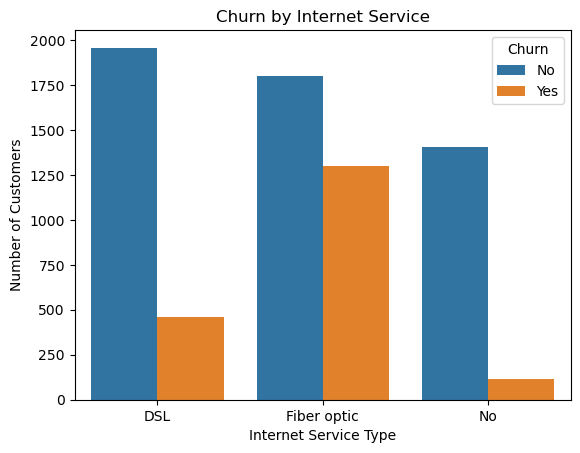

In [102]:
churn_internetservice = df.groupby('InternetService')['Churn'].value_counts()
print(churn_internetservice)
sns.countplot(x= 'InternetService', hue= 'Churn', data=df)
plt.title("Churn by Internet Service")
plt.xlabel("Internet Service Type")
plt.ylabel("Number of Customers")

plt.show()

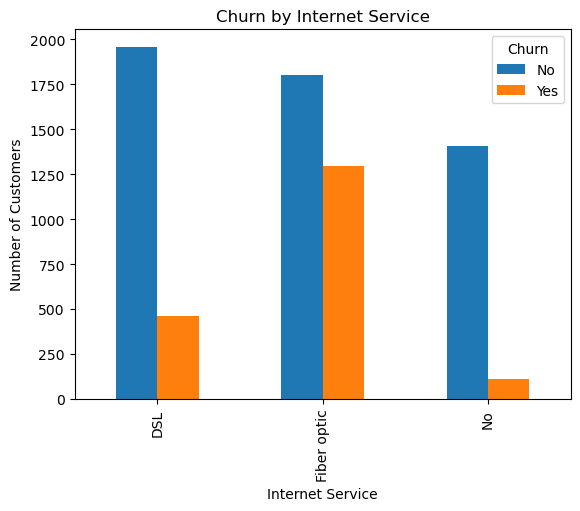

In [104]:
churn_internetservice = df.groupby('InternetService')['Churn'].value_counts().unstack()
churn_internetservice.plot(kind='bar')

plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

### Now we can see the correlation of the numerical columns

In [117]:
df['PaperlessBilling'].value_counts()

Yes    4168
No     2864
Name: PaperlessBilling, dtype: int64

In [120]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn Risk,TenureGroup,AvgMonthlySpend
0,Female,0,NaN,0,1,0,No phone service,DSL,No,Yes,...,No,Month-to-month,1,Electronic check,29.85,29.85,0,Low Risk,0-12 months,29.850000
1,Male,0,NaN,0,34,1,No,DSL,Yes,No,...,No,One year,0,Mailed check,56.95,1889.50,0,Medium Risk,25-36 months,55.573529


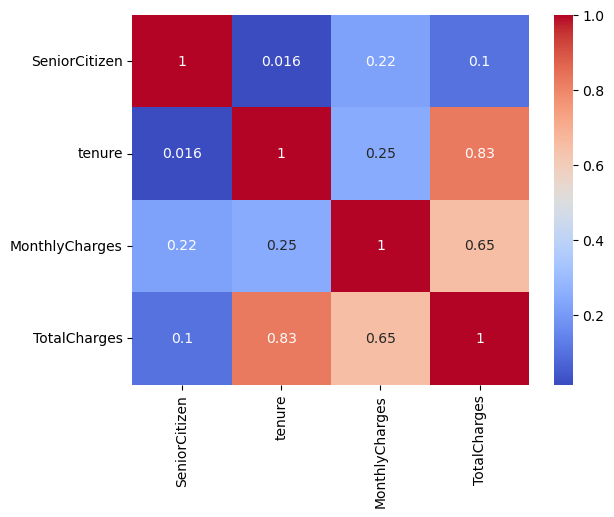

In [55]:
#Correlation among numerical columns
corr = df.corr()
sns.heatmap(corr, annot = True, cmap= 'coolwarm')
plt.show()